In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("Crop_recommendation.csv")

In [17]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [18]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [19]:
df.shape

(2200, 8)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [21]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [22]:
df.dtypes

N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object

In [23]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

array([[<Axes: title={'center': 'N'}>, <Axes: title={'center': 'P'}>,
        <Axes: title={'center': 'K'}>],
       [<Axes: title={'center': 'temperature'}>,
        <Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'ph'}>],
       [<Axes: title={'center': 'rainfall'}>, <Axes: >, <Axes: >]],
      dtype=object)

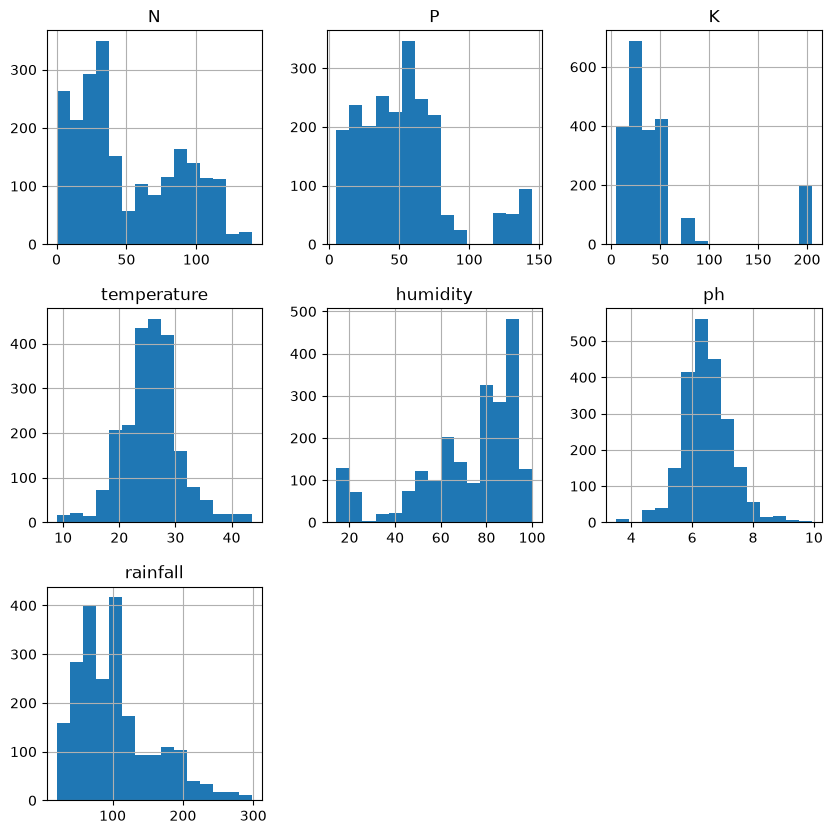

In [24]:
df.hist(bins=15,figsize=(10,10))
plt.savefig("Histogram Analysis")

<Axes: ylabel='temperature'>

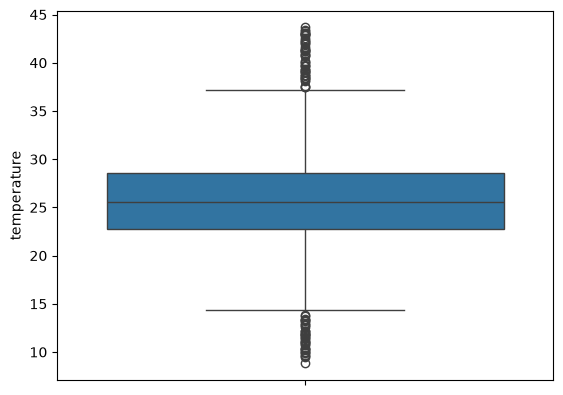

In [25]:
sns.boxplot(y='temperature',data=df)
plt.savefig("Outlier Temperature ")

<Axes: ylabel='humidity'>

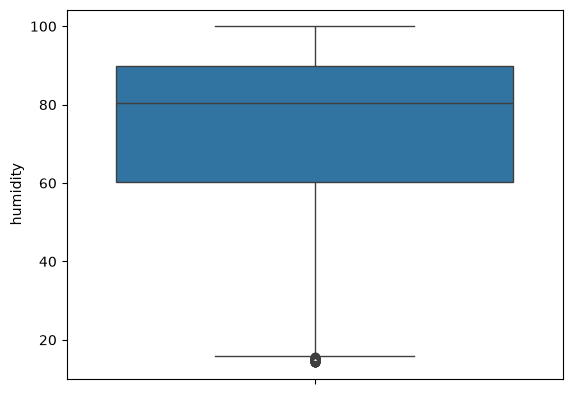

In [26]:
sns.boxplot(y='humidity',data=df)
plt.savefig("Outlier Humidity")

<Axes: ylabel='ph'>

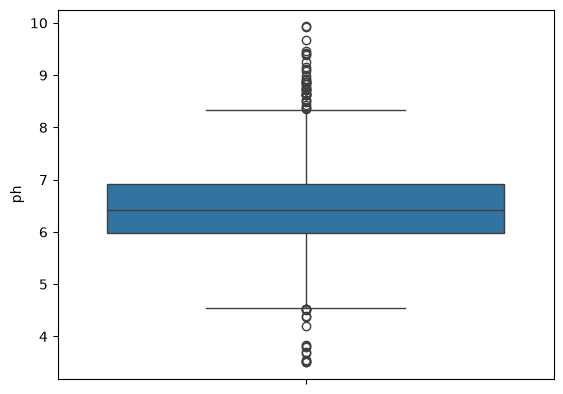

In [27]:
sns.boxplot(y='ph',data=df)
plt.savefig("Outlier ph")

<Axes: ylabel='N'>

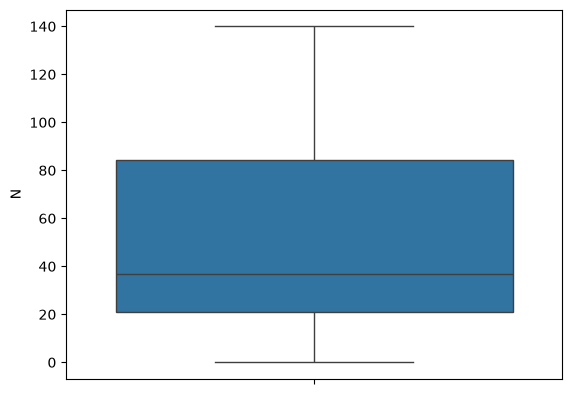

In [28]:
sns.boxplot(y='N',data=df)
plt.savefig("Outlier N ")

<Axes: ylabel='K'>

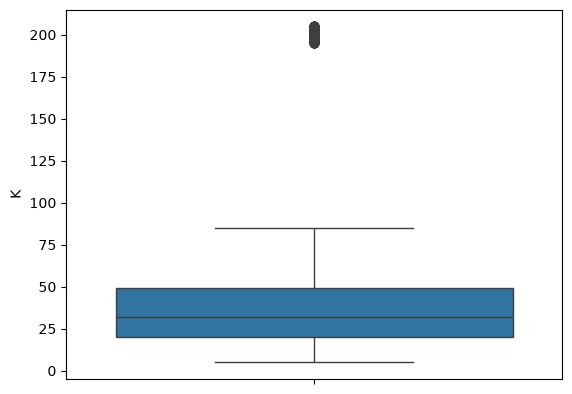

In [29]:
sns.boxplot(y='K',data=df)
plt.savefig("Outlier K")

<Axes: ylabel='P'>

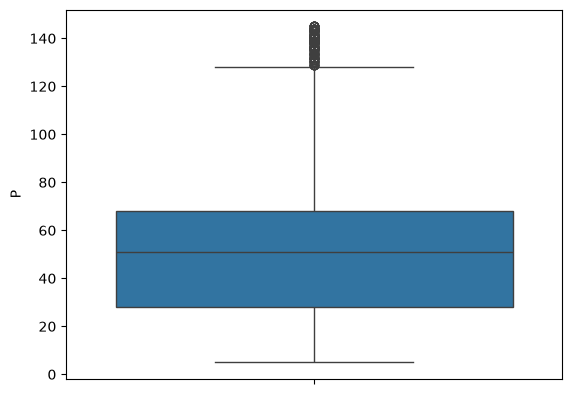

In [30]:
sns.boxplot(y='P',data=df)
plt.savefig("Outlier P")

<Axes: ylabel='P'>

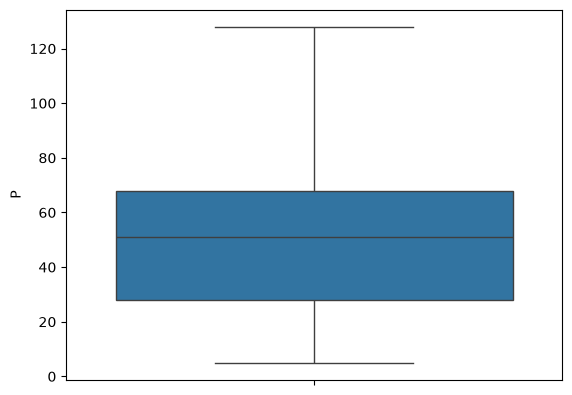

In [31]:
def remove_outliers(col_name):
  sorted(col_name)
  Q1,Q3 = col_name.quantile([0.25,0.75])
  IQR = Q3-Q1
  lower_range = Q1-(1.5*IQR)
  upper_range = Q3+(1.5*IQR)
  return lower_range,upper_range

low,high = remove_outliers(df['P'])

df['P'] = np.where(df['P']>high,high,np.where(df['P']<low,low,df['P']))

sns.boxplot(y='P',data=df)

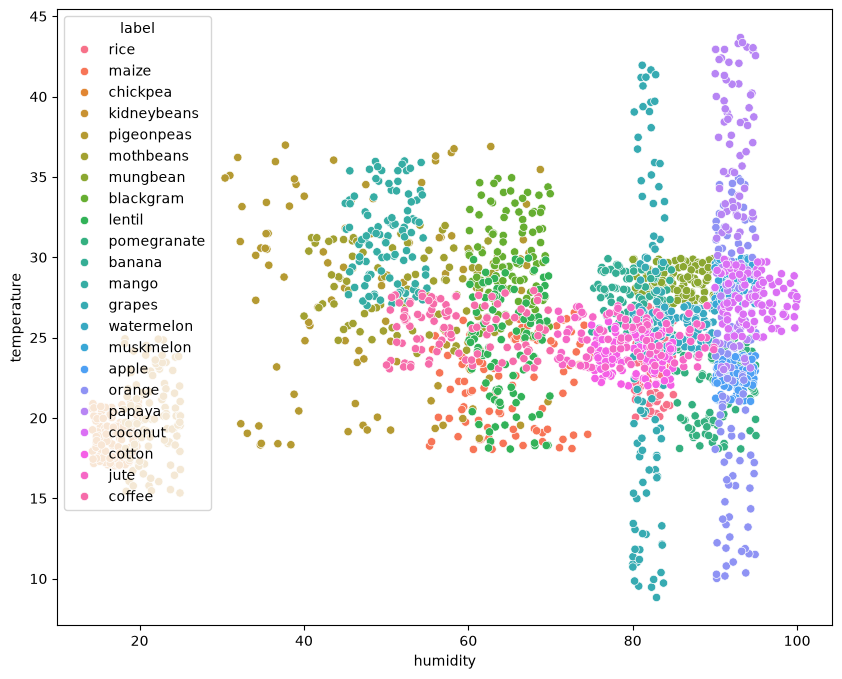

C:\Users\Pushpendra\AppData\Local\Temp\ipykernel_12596\2291571183.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="label", y="ph", data=df, palette="Set3")


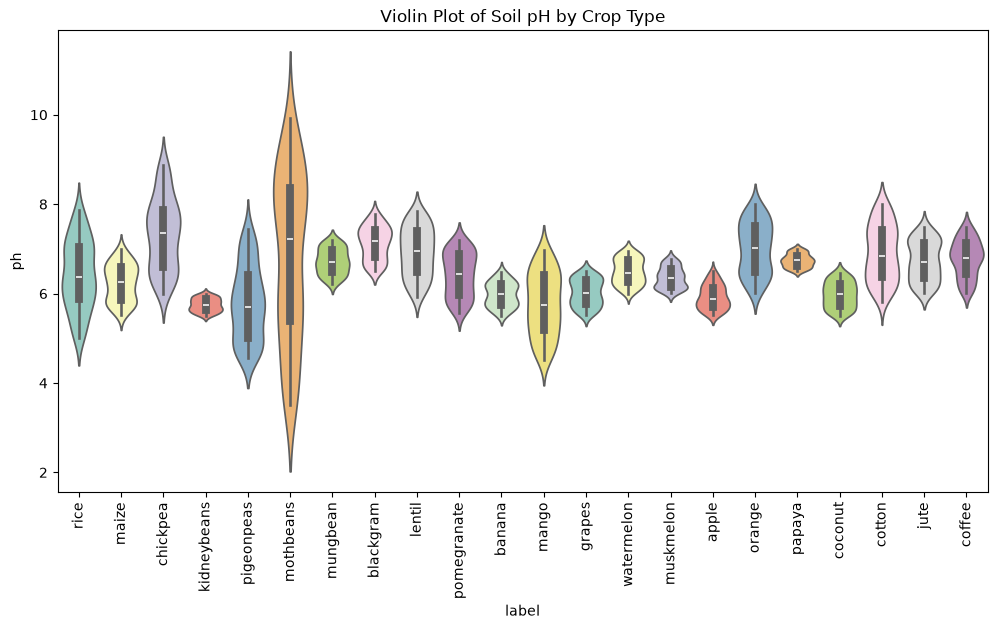

In [32]:
#Humidity VS Temperature
plt.figure(figsize=(10,8))
sns.scatterplot(x='humidity',y='temperature',data=df,hue='label')
plt.savefig("Scatterplot")
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(x="label", y="ph", data=df, palette="Set3")
plt.title("Violin Plot of Soil pH by Crop Type")
plt.savefig("Violin Plot of Soil pH by Crop Type")
plt.xticks(rotation=90)
plt.show()
